# Assignment 5: Neuroevolution

**Goal**: Implement an Evolutionary Algorithm to optimize an Artificial Neural Network (ANN) based controller for the CartPole task in OpenAI Gym environment.

**Note**: All assignments are individual, group work and/or the use of generative AI tools for completing the assignments in any capacity and/or copy paste from any resource are considered as plagiarism and reported.

CartPole evaluation environment functions are provided. Your goal is to implement your ANN to control the cartpole and use your Evolutionary Algorithm to optimize the ANN parameters (weights).

Please answer the `Questions` and implement coding `Tasks` by filling **PLEASE FILL IN** sections. *Documentation* of your code is also important. You can find the grading scheme in implementation cells.

**Install Prerequisites**

In [ ]:
# Run this cell to install the required libraries
%pip install numpy matplotlib scipy

**Imports**

In [9]:
# Necessary libraries
import matplotlib.pyplot as plt
import numpy as np

In [10]:
# Enables inline matplotib graphs
%matplotlib inline
# Comment the line above and uncomment the lines below to have interactive plots
# WARN: may cause dependency issues
# %matplotlib qt5
# %pip install PyQt5
# plt.ion()

In [11]:
# %pip install gymnasium
import gymnasium as gym

---
**Question 1 (0-0.25-0.5 pt):** Following link provides more information about the CartPole environemnt we would like to find an ANN to control: https://www.gymlibrary.dev/environments/classic_control/cart_pole/

Please have a look at the link and note the observation and action spaces, how many dimensions they have? Are they continous or discrete, and what kinds of value they can get?

**Answer:**  

The values of the action space are discrete and $\in {0, 1}$. The action consists of one value only, i.e. of shape `(1,)`.  
The observations are `ndarray`s with shape `(4,)` consisting of 4 real values (that is, observation space is continiuos). Each of the values must be within its range: cart position $\in (-4.8, 4.8)$, cart velocity and pole angular velocity are each $\in (-\infty, \infty)$, pole angle $\in (-.418, .418)$.

---
**Question 2 (0-0.25-0.5 pt):** What is your proposed ANN architecture and why? Please also discuss the activation functions you choose.

**Answer:**  

The proposed ANN architecture here is simply two fully connected layers with one hidden layer: `4 (In) > 32 (h) tanh > 1 (Out) sigmoid`, `tanh` function after the first FC layer and `sigm` function as the last activation function. We believe that since the input and output data are low-dimensional, an MLP (with just 2 layers) would be sufficient. `tanh` activation function was chosen so that it does not "kill" negative neurons and zero-centered. `sigm` possesses alike properties.

---
**Task 1: Implementation of Evolutionary Algrotihm (0-1.6-3.8-4.2-5 pt):** Implement your evolutionary algorithm to find an ANN controller for the CartPole task.

In [58]:
#################################
# Grading
# 0 pts if the code does not work, code works but it is fundamentally incorrect
# 1.6 pts if the code works but some functions are incorrect and it is badly explained
# 3.8 pts if the code works but some functions are incorrect but it is explained well
# 4.2 pts if the code works very well aligned with the task without any mistakes, but it is badly explained
# 5 pts if the code works very well aligned with the task without any mistakes, and it is well explained
################################################################


# Artificial Neural Network parameters (weights)
# See here: https://www.gymlibrary.dev/environments/classic_control/cart_pole/ for input and output space
# PLEASE SPECIFY BELOW
inp = 4 # Number of input neurons
hid = 32 # Number of hidden neurons
out = 1 # Nubmer of output neurons
###################


def weights(x):
    '''
    in neuroevolution, x represents an individual in the population, which is a vector of real numbers -- weights
    this function maps the vector of weights to the connection weights of the ANN
    '''
    W1 = x[:inp*hid].reshape(inp, hid)  # weights between input and hidden layer
    W2 = x[inp*hid:].reshape(hid, out)  # weights between hidden and output layer
    return W1, W2


def ann(observation, W1, W2):
    '''
    this is the forward pass of the ann, i.e. how the ANN processes the input to produce an output
    '''

    # we take first the input, then we calculate the hidden layer activations using the weights W1 and an activation function (tanh in our case)
    hidden = np.tanh(np.dot(observation, W1))

    # then we calculate the output layer activations using the weights W2 and an activation function (sigmoid in our case)
    output = 1 / (1 + np.exp(-np.dot(hidden, W2)))

    return output


#Open AI gym environment
env = gym.make("CartPole-v1")

# CartPole evaluation function
def cartpole(x):

    ###########
    # PLEASE FILL IN
    # Hint: x is an individual in evolutionary algorithms and needs to map to the connection weights of ANNs
    W1, W2 = weights(x)  # get weights from the individual x
    #########

    # Reset environment
    observation, info = env.reset(seed = 0)

    rew = 0 # Initial reward
    step = 0; #step counter
    done = False
    maxStep = 1000  # maximum number of steps
    while not done and step<1000:

      ###################
      # PLEASE FILL IN
      # Hint: Provide input to ANN and find the output to be the action
      
      # first, get the results from the ANN by providing the observation and the weights
      res = ann(observation, W1, W2)
      # evaluating the output to get the action (0 or 1)
      action = 0 if res < 0.5 else 1

      # action should be provided based on the output of the artifial neural network
      observation, reward, done, tr, info = env.step(action)
      step += 1 # step counter
      rew = rew + reward # after each step increment reward

    env.close()
    return np.minimum(maxStep, rew) # return the reward or maxStep (if maxStep < 1000, this means that pole fell)



# CartPole evaluation function with video recording
def cartpole_record_video(x):
    tmp_env = gym.make("CartPole-v1", render_mode="rgb_array")

    # Video recording function - be sure to check the folder path - you should see the video here:content/video/cartpole
    video_env = gym.wrappers.RecordVideo(env=tmp_env, video_folder="content/video/cartpole", name_prefix="cartpole")

    ###########
    # PLEASE FILL IN
    # Hint: x is an individual in evolutionary algorithms and needs to map to the connection weights of ANNs
    W1, W2 = weights(x)  # same here, get the weights from the individual x
    #########


    # Reset environment
    observation, info = video_env.reset(seed = 0)

    video_env.start_video_recorder()


    rew = 0 # Initial reward
    step = 0; #step counter
    done = False
    maxStep = 1000  # maximum number of steps
    while not done and step<1000: # run nStep number of time

      ###################
      # PLEASE FILL IN
      # Hint: Provide input to ANN and find the output to be the action
      res = ann(observation, W1, W2)  # and here, get the results from the ANN by providing the observation and the weights
      action = 0 if res < 0.5 else 1  # evaluating the output to get the action (0 or 1)


      # action should be provided based on the output of the artifial neural network
      observation, reward, done, tr, info = video_env.step(action)
      step+=1 # step counter
      rew = rew + reward # after each step increment reward
      video_env.render()

    video_env.close_video_recorder()
    video_env.close()
    return np.minimum(maxStep, rew) # return the reward or maxStep (if maxStep < 1000, this means that pole fell)




# CartPole evaluation function for visualizing the cartpole environment
def cartpole_visualize(x):
    tmp_env = gym.make("CartPole-v1", render_mode="human")

    ###########
    # PLEASE FILL IN
    # Hint: x is an individual in evolutionary algorithms and needs to map to the connection weights of ANNs
    W1, W2 = weights(x)  # one more time, we had better make a function for this
    #########

    # Reset environment
    observation, info = tmp_env.reset(seed = 0)

    rew = 0 # Initial reward
    step = 0; #step counter
    done = False
    maxStep = 1000  # maximum number of steps
    while not done and step<1000: # run nStep number of time

      ###################
      # PLEASE FILL IN
      # Hint: Provide input to ANN and find the output to be the action
      res = ann(observation, W1, W2)  # results from the ANN
      action = 0 if res < 0.5 else 1  # predicting action

      # action should be provided based on the output of the artifial neural network
      observation, reward, done, tr, info = tmp_env.step(action)
      step+=1 # step counter
      rew = rew + reward # after each step increment reward
      tmp_env.render()

    tmp_env.close()
    return np.minimum(maxStep, rew) # return the reward or maxStep (if maxStep < 1000, this means that pole fell)


def initialization(population_size, num_dimensions=160):
    """
    Initialize the starting population with random individuals.
    Each gene of an individual corresponds to a point on a dimension in the function
    """

    # number of dimensions is the number of weights in the ANN (inp*hid + hid*out) = 4*32 + 32*1 = 160
    # we don't know the optimal weights, so we can safely initialize them randomly between -1 and 1
    x = np.random.uniform(low=-1.0, high=1.0, size=(population_size, num_dimensions))
    return x

def evaluation(x, objective_function):
  '''
  getting the fitness of each individual in the population by evaluating them on the objective function (cartpole in our case)
  '''
  fitness = np.array([objective_function(ind) for ind in x])
  return fitness

def crossover(x_parents, p_crossover):
    '''
    Perform crossover to create offsprings.
    We will use one-point crossover
    '''

    # retreiving some parameters
    offspring = x_parents.copy()
    num_parents, num_dims = x_parents.shape
    
    for i in range(0, num_parents, 2):
        if np.random.rand() < p_crossover:  # crossover with probability p_crossover: if crossover does not happen, offspring are just copies of parents
            threshold = np.random.randint(1, num_dims)  # randomly select a crossover point
            p1, p2 = offspring[i].copy(), offspring[i + 1].copy()  # get the two parents: p1 and p2

            # first offspring gets the first part of p1 and the second part of p2
            offspring[i, :threshold] = p1[:threshold]
            offspring[i, threshold:] = p2[threshold:]

            # second offspring gets the first part of p2 and the second part of p1 (quite straightforward)
            offspring[i + 1, :threshold] = p2[:threshold]
            offspring[i + 1, threshold:] = p1[threshold:]

    return offspring

def mutation(x, mutation_rate):
    '''
    Apply mutation to an individual.
    We will add gaussian noise to the weights with a certain mutation rate.
    '''
    mutated = x.copy()

    # for the sake of efficiency, we will generate noise in the form of a matrix
    noise = np.random.normal(0.0, 0.1, x.shape)

    # then we apply the mutation to all individuals and then we will select which ones to mutate based on the mutation rate
    mask = np.random.random(x.shape) < mutation_rate  # this creates a boolean mask where True means mutation will be applied
    mutated[mask] += noise[mask]  # and we apply mutation only to the selected genes
    return np.clip(mutated, -5, 5)  # clipping to prevent exploding weights (which is unlikely)

def parent_selection(x, f, tournament_size=7):
    '''
    Select parents for the next generation using tournament selection
    I did not implement roulette as in assignment 2 because I just want to practice tournament selection hahaha 
    '''
    
    size = len(x)
    # creating arrays to hold the selected parents and their fitness
    x_parents = np.zeros_like(x)
    f_parents = np.zeros_like(f)
    
    for i in range(size):
      # we randomly select 7 individuals from the population to compete in the tournament
      idx = np.random.choice(size, size=tournament_size, replace=False)

      # then we select the best individual among the 7 selected individuals to be the parent for the next generation
      best_idx = idx[np.argmax(f[idx])]
      x_parents[i] = x[best_idx]
      f_parents[i] = f[best_idx]
      # and this is it, we repeat this process until we have selected enough parents for the next generation

    return x_parents, f_parents

def survivor_selection(x, f, x_offspring, f_offspring):
    '''
    Select the survivors for next generation
    '''
    # we combine the parents and the offsprings into one population
    x_combined = np.vstack((x, x_offspring))
    f_combined = np.hstack((f, f_offspring))
    
    # we sort the combined population based on fitness and select the top individuals to be the survivors for the next generation
    indices = np.argsort(f_combined)[-len(x):]  # and take top len(x) indices (the same number as the original population size)
    x = x_combined[indices]
    f = f_combined[indices]
    return x, f


def ea(population_size, max_fit_evals, p_crossover, m_rate, objective_function):
    max_generations = int(max_fit_evals / population_size)
    
    x = initialization(population_size, num_dimensions=160)
    f = evaluation(x, objective_function)
    
    # we will track the best individual and its fitness at each generation
    idx = np.argmax(f)  # get the index of the best individual in the initial population
    x_best = [x[idx].copy()]
    f_best = [f[idx]]
    
    for i in range(max_generations - 1):
        x_parents, f_parents = parent_selection(x, f)
        x_offspring = crossover(x_parents, p_crossover)
        x_offspring = mutation(x_offspring, m_rate)
        f_offspring = evaluation(x_offspring, objective_function)
        x, f = survivor_selection(x, f, x_offspring, f_offspring)
        
        # here we track the best individual each generation
        idx = np.argmax(f)
        xi_best = x[idx].copy()
        fi_best = f[idx]
        if fi_best > f_best[-1]:
            x_best.append(xi_best)
            f_best.append(fi_best)
        else:
            x_best.append(x_best[-1])
            f_best.append(f_best[-1])
    
    return np.array(x_best), np.array(f_best)

#### Check Your Implementation: Running The Evolutionary Algorithm

Run the cell below, if you implemented everything correctly, you should see the algorithm running. Furthermore,

In [60]:
# Dummy parameters, please add or remove based on your implementation
kwargs = {
    "population_size": 20,
    "max_fit_evals": 1000,  # maximum number of fitness evaluations
    "p_crossover": 0.9,  # crossover probability
    "m_rate": 0.1,  # mutation rate
    "objective_function": cartpole,
}
# Run your algorithm once and find the best ANN weigths found
env = gym.make("CartPole-v1")
x_best, f_best = ea(**kwargs)


# Print the best ANN weigths found and best fitness
print("Best ANN parameters found:",x_best[-1])
print("Best fitness found:",f_best[-1])


# Evaluate your ANN weights again and record the video
if f_best[-1] >= 1000:
  # cartpole_record_video(x_best[-1])
  cartpole_visualize(x_best[-1])
else:
  print("The best fitness 1000 was not found, try again!!")

Best ANN parameters found: [ 0.55480533  0.63535688  0.22307324  0.65792722  0.38974731 -0.41579473
 -0.42171546  0.67301999 -0.4546673  -0.90022202 -0.54122861 -0.28568802
  0.84992339  0.86366602  0.74273817 -0.07338799 -0.91788531  0.6639698
  0.66261914  0.59193623 -0.25092381  0.31478571 -0.42672809 -0.85424229
  0.7019458   0.18597541 -0.42489147 -0.58361777  0.44350341  0.28419059
 -0.67542737 -0.23461544  0.4929858  -0.49087194  0.8052953  -0.72193631
 -0.80649094 -0.01944547 -0.182936    0.77549663  0.66976257  0.7449712
  0.36071234 -0.62624158 -0.99894986 -0.883371    0.53557831 -0.85134335
  0.47211531  0.90896376 -0.26913151 -0.83056057  0.25884739  0.41196948
  0.475619   -0.89446296 -0.89585975  0.77240445  0.07461539 -0.22922443
  0.8808015   0.07032913 -0.49610214 -0.4245502   0.80218808  0.3226737
  0.21928162  0.38133871 -0.57311756 -0.19403826 -0.80273739  1.17342215
  0.31789201  0.45487216 -0.80668742 -0.69954246 -0.65642439  0.09211485
 -0.45234795  0.70678272  0

---
**Question 3 (0-0.25-0.5 pt):** Please comment on the behavior of the final solution. Were you able to find the best solution (i.e. ANN weights which achieves best fitness: 1000) and was it possible to controll the CartPole task without letting the the pole fall?

**Answer:**  
Yes, it seems that best fitness was reached successfully, the pole did not fall. Interestingly, all the weights are within or almost within $[-1, 1]$, so we did get neither the explosion of the weights, nor decaying of the weights (as it could possibly occur when using backprop (but not on this tiny NN)).  

**Average results of your algorithm**

Remember that the EAs are sthocastic algorithms that can produce different results as a result of independent runs.

Therefore, we would like to see the average results and standard deviations.


---
**Task 2 (0-1.5-3 pt):** Please run your algorithm for at least 10 times and plot the average results and standard deviations. Below, you may add as many cells as you need for this implementation and plot functions. You may use previous code you have developed/used during the course.

**Some helper functions**

In [61]:
def calculate_mean_std(f_best):
    """This is a helper function to calculate the mean and standard deviation of the best fitness values.
    This function was borrowed from the second assignment"""
    f_best = np.array(f_best)
    avg = np.mean(f_best, axis=0)
    std = np.std(f_best, axis=0)
    return avg, std

In [ ]:
def run_cartpole_experiment(population_size, p_crossover, m_rate, num_runs=10):
    '''
    We run the cartpole EA mulyiple times 
    '''
    max_fit_evals = 1000
    
    all_runs = []  # list to track the best fitness values from all runs
    
    print(f'running {num_runs} runs')
    for run in range(num_runs):  # running the EA num_runs times
        print(f'{run+1}/{num_runs}')
        _, f_best = ea(
            population_size=population_size,
            max_fit_evals=max_fit_evals,
            p_crossover=p_crossover,
            m_rate=m_rate,
            objective_function=cartpole,
        )
        all_runs.append(f_best)  # appending the best fitness values from this run to the all_runs list
    
    # statistics
    avg, std = calculate_mean_std(all_runs)
    
    return [avg], [std], all_runs

In [ ]:
def plot_cartpole_results(avgs, stds, labels):
    '''
    Here we plot the average best fitness + std dev with shaded regions.
    '''
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # plot mean + std dev shaded region
    generations = np.arange(len(avgs[0]))


    ax.plot(generations, avgs[0], label=labels[0], color='navy', linewidth=2)
    ax.fill_between(
        generations,
        avgs[0] - stds[0],
        avgs[0] + stds[0],
        alpha=0.3, color='navy', label='±1 std dev'
    )
    
    ax.set_xlabel('Generations')
    ax.set_ylabel('Best fitness')
    ax.set_title('CartPole ANN')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

**Running the experiments and plotting the results**

running 12 runs
1/12
2/12
3/12
4/12
5/12
6/12
7/12
8/12
9/12
10/12
11/12
12/12


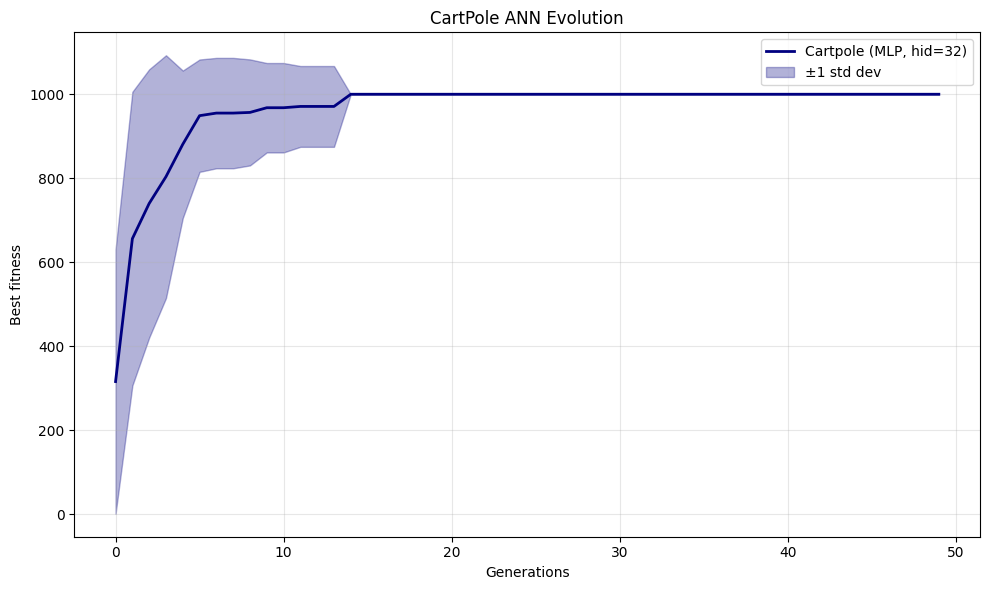


final results (after 50 generations):
average best fitness: 1000.0 +/- 0.0


In [57]:
avgs, stds, all_runs = run_cartpole_experiment(
        population_size=20,
        p_crossover=0.9,
        m_rate=0.1,
        num_runs=12  
    )
    
plot_cartpole_results(
    avgs=avgs,
    stds=stds, 
    labels=['Cartpole (MLP, hid=32)']
)


final_avg = avgs[0][-1]
final_std = stds[0][-1]
print(f'\nfinal results (after {len(avgs[0])} generations):')
print(f'average best fitness: {final_avg:.1f} +/- {final_std:.1f}')

---
**Question 4 (0-0.25-0.5 pt):** Please comment on the average behavior of your algorithm. How did the average results and standard deviations look? Did your algorithm converge all the time to the best fitness?

**Answer:**  

On average, the ANN converges to 1000 fitness value after the 15th generation. Standard deviation also gradually decreases to zero after the same 15th generation. According to the graph and average best fitness, our ANN converges throughout all the 12 runs. I suspect that it might be because of the size of the hidden layer (32 neurons) which is quite large number for $\mathbb{R}^{4} \to \mathbb{R}^{1}$